# Controlled comparison of labeling method with real data

In [13]:
from pathlib import Path
from collections import defaultdict
from typing import Dict, List, Tuple, Union

import numpy as np
import pandas as pd
import json
import pysam
import cvxpy as cp
from tqdm import tqdm
import matplotlib.pyplot as plt

from utils import (
    filename2ctype,
    nested_defaultdict_to_dict,
    get_idx_from_sig,
    get_sig_from_idx,
    nrmse,
)

## Miscellaneus utils

In [14]:
def extract_complete_dataset(reads_ds):
    """
    Create a complete dataset from a given reads_ds dataset
    by splitting long patterns into all possible subpatterns and storing the counts.
    """
    complete_dataset = defaultdict(
        lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
    )
    for ctype, length_dict in reads_ds.items():
        for read_length in sorted(length_dict.keys()):
            for start, pattern_counts in length_dict[read_length].items():
                for pattern, n_reads in pattern_counts.items():
                    # add the original pattern to the complete dataset
                    complete_dataset[ctype][len(pattern)][start][pattern] += n_reads
                    # split the pattern into all possible subpatterns
                    for sub_length in range(1, len(pattern)):
                        for sub_start in range(len(pattern) - sub_length + 1):
                            subpattern = pattern[sub_start : sub_start + sub_length]
                            if len(subpattern) == 0:
                                continue  # skip empty subpatterns
                            complete_dataset[ctype][len(subpattern)][start + sub_start][
                                subpattern
                            ] += n_reads
    return complete_dataset

In [15]:
def compute_num_reads_in_dataset(dataset):
    """
    Compute the total number of reads in a given dataset
    """
    total_reads = 0
    for ctype, length_dict in dataset.items():
        for read_length, start_dict in length_dict.items():
            for start, pattern_counts in start_dict.items():
                total_reads += sum(pattern_counts.values())
    return total_reads

In [16]:
def generate_bootstrap_sample_from_dataset(
    source_dataset, ratio=None, dataset_size_to_sample=None
):
    """
    Generate a bootstrap sample from a given dataset by sampling with replacement the reads.
    """
    assert (
        dataset_size_to_sample is not None or ratio is not None
    ), "Either dataset_size_to_sample or ratio must be provided"
    size_source_dataset = compute_num_reads_in_dataset(source_dataset)
    if ratio is not None:
        assert 0 < ratio, "Ratio must be > 0 (can be > 1 for oversampling)"
        dataset_size_to_sample = int(size_source_dataset * ratio)

    # create a list of all reads in the source dataset
    unique_reads = []
    counts_per_read = []
    for ctype, length_dict in source_dataset.items():
        for read_length, start_dict in length_dict.items():
            for start, pattern_counts in start_dict.items():
                for pattern, n_reads in pattern_counts.items():
                    unique_reads.append((ctype, read_length, start, pattern))
                    counts_per_read.append(n_reads)
    counts_per_read = np.array(counts_per_read)

    # sample with replacement the reads
    sampled_indices = np.random.choice(
        len(unique_reads),
        size=dataset_size_to_sample,
        replace=True,
        p=counts_per_read / counts_per_read.sum(),
    )
    sampled_reads = [unique_reads[i] for i in sampled_indices]

    # create the bootstrap sample dataset
    bootstrap_sample_dataset = defaultdict(
        lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
    )
    for ctype, read_length, start, pattern in sampled_reads:
        bootstrap_sample_dataset[ctype][read_length][start][pattern] += 1
    return bootstrap_sample_dataset

In [17]:
def compute_counts_sig_per_ctype_from_dataset(
    dataset, sig_positions, selected_ctypes_, n_ctypes
) -> Dict[int, Dict[int, np.ndarray]]:
    """
    Compute the counts of signatures per ctype from a given dataset.

    Returns:
        counts_sig_per_ctype: Dict[int, Dict[int, np.ndarray]]
            A dictionary where the keys are the start positions of the signatures,
            and the values are dictionaries where the keys are the read lengths and
            the values are 2D numpy arrays of shape (n_ctypes, 2**read_length) containing
            the counts of each signature for each ctype.
    """
    counts_sig_per_ctype = {}
    for start, read_lengths in sig_positions.items():
        counts_sig_per_ctype[start] = {}
        for read_length in read_lengths:
            counts_sig_per_ctype[start][read_length] = np.zeros(
                (n_ctypes, 2**read_length), dtype=int
            )
            for ctype_idx, ctype in enumerate(selected_ctypes_):
                pattern_counts = dataset[ctype][read_length][start]
                for pattern, n_reads in pattern_counts.items():
                    pattern_idx = get_idx_from_sig(pattern)
                    counts_sig_per_ctype[start][read_length][
                        ctype_idx, pattern_idx
                    ] += n_reads
    return counts_sig_per_ctype

In [18]:
def compute_pgt_sig_prior_from_counts(counts_sig_per_ctype, sig_pos_):
    """
    Compute the prior probabilities of signatures per ctype from the counts of signatures.
    """
    pgt_sig_prior = {}
    for start, read_lengths in sig_pos_.items():
        pgt_sig_prior[start] = {}
        for read_length in read_lengths:
            counts_sig_per_ctype_ = counts_sig_per_ctype[start][read_length]
            pgt_sig_prior[start][read_length] = (
                counts_sig_per_ctype_.sum(axis=0) / counts_sig_per_ctype_.sum()
            )
    return pgt_sig_prior

In [39]:
def compute_nrmse_per_sig_length(
    predicted_proba_sig_per_ctype: Dict[int, Dict[int, np.ndarray]],
    true_proba_sig_per_ctype: Dict[int, Dict[int, np.ndarray]],
    counts_sig_per_ctype: Dict[int, Dict[int, np.ndarray]] = None,
    min_count_threshold_per_ctype: int = None,
):
    """
    Compute the normalized root mean square error (NRMSE) between the predicted and true probabilities of signatures per ctype,
    for a whole set of signature positions (ie start and read_length combinations).
    The average is computed per signature length, to avoid confusion.

    It is possible to provide a counts_sig_per_ctype and a min_count_threshold_per_ctype to filter out the signature positions with too low counts
    for a given ctype.
    """
    nrmse_list_per_length = defaultdict(list)
    num_sig_ctype_pairs_considered_per_length = defaultdict(int)
    for start, read_lengths in predicted_proba_sig_per_ctype.items():
        for read_length, predicted_proba in read_lengths.items():
            true_proba = true_proba_sig_per_ctype[start][read_length]
            if min_count_threshold_per_ctype is not None:
                if counts_sig_per_ctype is None:
                    raise ValueError(
                        "If min_count_threshold_per_ctype is provided, counts_sig_per_ctype must also be provided"
                    )
                tmp_ctype_counts = counts_sig_per_ctype[start][read_length].sum(axis=1)
                ctype_mask = tmp_ctype_counts >= min_count_threshold_per_ctype
                predicted_proba = predicted_proba[ctype_mask]
                true_proba = true_proba[ctype_mask]
            # Skip computing NRMSE if there's no data after filtering
            if len(predicted_proba) == 0:
                continue
            nrmse_ = nrmse(true_proba, predicted_proba, return_per_sample=True)
            nrmse_list_per_length[read_length].extend(nrmse_)
            num_sig_ctype_pairs_considered_per_length[read_length] += len(
                predicted_proba
            )
    avg_nrmse_per_length = {
        read_length: np.mean(nrmse_list)
        for read_length, nrmse_list in nrmse_list_per_length.items()
        if len(nrmse_list) > 0
    }
    return avg_nrmse_per_length, num_sig_ctype_pairs_considered_per_length


def compute_nrmse_per_sig_length_ctype_given_sig(
    predicted_proba_ctype_given_sig: Dict[int, Dict[int, np.ndarray]],
    true_proba_ctype_given_sig: Dict[int, Dict[int, np.ndarray]],
    counts_sig_per_ctype: Dict[int, Dict[int, np.ndarray]] = None,
    min_count_threshold_per_signature: int = None,
    max_count_threshold_per_signature: int = None,
):
    """
    Compute NRMSE between predicted and true P(ctype | signature) distributions.

    predicted_proba_ctype_given_sig[start][read_length] and
    true_proba_ctype_given_sig[start][read_length] must have shape
    (2**read_length, n_ctypes).

    Optionally, signatures with total counts below min_count_threshold_per_signature
    or above max_count_threshold_per_signature are filtered out before the NRMSE computation.
    """
    nrmse_list_per_length = defaultdict(list)
    num_sigs_considered_per_length = defaultdict(int)
    for start, read_lengths in predicted_proba_ctype_given_sig.items():
        for read_length, predicted_proba in read_lengths.items():
            true_proba = true_proba_ctype_given_sig[start][read_length]

            if (
                min_count_threshold_per_signature is not None
                or max_count_threshold_per_signature is not None
            ):
                if counts_sig_per_ctype is None:
                    raise ValueError(
                        "If min_count_threshold_per_signature or max_count_threshold_per_signature is provided, counts_sig_per_ctype must also be provided"
                    )
                tmp_sig_counts = counts_sig_per_ctype[start][read_length].sum(axis=0)
                if min_count_threshold_per_signature is not None:
                    sig_mask_min = tmp_sig_counts >= min_count_threshold_per_signature
                else:
                    sig_mask_min = np.ones_like(tmp_sig_counts, dtype=bool)
                if max_count_threshold_per_signature is not None:
                    sig_mask_max = tmp_sig_counts <= max_count_threshold_per_signature
                else:
                    sig_mask_max = np.ones_like(tmp_sig_counts, dtype=bool)
                sig_mask = sig_mask_min & sig_mask_max
                predicted_proba = predicted_proba[sig_mask]
                true_proba = true_proba[sig_mask]

            if len(predicted_proba) == 0:
                continue

            nrmse_ = nrmse(true_proba, predicted_proba, return_per_sample=True)
            nrmse_list_per_length[read_length].extend(nrmse_)
            num_sigs_considered_per_length[read_length] += len(predicted_proba)

    avg_nrmse_per_length = {
        read_length: np.mean(nrmse_list)
        for read_length, nrmse_list in nrmse_list_per_length.items()
        if len(nrmse_list) > 0
    }
    return avg_nrmse_per_length, num_sigs_considered_per_length

## Methods definitions

### Methods for pure samples only

In [20]:
# Naive soft labels without pooling
def naive_sl_without_pooling(counts_sig_per_ctype: Dict[int, Dict[int, np.ndarray]]):
    """
    Compute P(sig | ctype) by normalizing the counts of signatures per ctype.
    Can only be applied to PURE samples, where we know exactly the ctype from which
    each read comes.
    """
    return {
        start: {
            read_length: counts / counts.sum(axis=1, keepdims=True)
            for read_length, counts in read_lengths.items()
        }
        for start, read_lengths in counts_sig_per_ctype.items()
    }


def naive_sl_without_pooling_ctype_given_sig(
    counts_sig_per_ctype: Dict[int, Dict[int, np.ndarray]],
):
    """
    Compute P(ctype | sig) by normalizing the counts of signatures per ctype.
    Can only be applied to PURE samples, where we know exactly the ctype from which
    each read comes.
    """
    return {
        start: {
            read_length: (counts / counts.sum(axis=0, keepdims=True)).T
            for read_length, counts in read_lengths.items()
        }
        for start, read_lengths in counts_sig_per_ctype.items()
    }

In [91]:
# Naive soft labels with pooling
def jaccard_distance(sig1_data, sig2_data) -> float:
    """
    Compute the Jaccard distance between two signatures represented as (start, length, sig_idx).
    First we reconstruct the real signatures from the signature indices, then we compute the
    Jaccard distance between the two sets of CpG positions with status 1.
    """
    start1, len1, sig_idx1 = sig1_data
    start2, len2, sig_idx2 = sig2_data
    sig1 = get_sig_from_idx(sig_idx1, len1)
    sig2 = get_sig_from_idx(sig_idx2, len2)
    complete_sig1 = set((start1 + i, int(state)) for i, state in enumerate(sig1))
    complete_sig2 = set((start2 + i, int(state)) for i, state in enumerate(sig2))
    intersection = complete_sig1 & complete_sig2
    union = complete_sig1 | complete_sig2
    return 1 - len(intersection) / len(union) if union else 0.0


def naive_sl_with_pooling(
    counts_sig_per_ctype: Dict[int, Dict[int, np.ndarray]],
    pgt_sig_prior: Dict[int, Dict[int, np.ndarray]],
    dist_threshold: float = 0.41,
    min_counts: int = 30,
):
    """
    Compute P(sig | ctype) for every signature by first computing
    P(ctype | sig) (using soft labels with pooling) and then converting it
    to P(sig | ctype) using the pseudo ground truth prior P(sig).
    Can only be applied to PURE samples, where we know exactly the ctype from which
    each read comes.
    """
    # first we construct the list of all signatures with their start, length and index
    all_signatures = []
    for start, read_lengths in signature_positions.items():
        for read_length in read_lengths:
            n_signatures = 2**read_length
            for sig_idx in range(n_signatures):
                all_signatures.append((start, read_length, sig_idx))

    # then we compute the pairwise Jaccard distances between all signatures
    n_all_signatures = len(all_signatures)
    jaccard_distances = np.zeros((n_all_signatures, n_all_signatures))
    for i in range(n_all_signatures):
        for j in range(i + 1, n_all_signatures):
            jaccard_distances[i, j] = jaccard_distance(
                all_signatures[i], all_signatures[j]
            )
            jaccard_distances[j, i] = jaccard_distances[i, j]

    # for all signatures, we iterate over all signatures by ascending order of jacccard distance
    # and we pool the signatures that are within the distance threshold until
    # we reach the minimum counts threshold
    pooled_counts = np.zeros((n_all_signatures, N_CTYPES), dtype=int)
    for sig_global_idx, (start, read_length, sig_idx) in enumerate(all_signatures):
        ordered_closed_signatures = np.argsort(jaccard_distances[sig_global_idx])
        for close_sig_global_idx in ordered_closed_signatures:
            close_start, close_read_length, close_sig_idx = all_signatures[
                close_sig_global_idx
            ]
            if jaccard_distances[sig_global_idx, close_sig_global_idx] > dist_threshold:
                break
            pooled_counts[sig_global_idx] += counts_sig_per_ctype[close_start][
                close_read_length
            ][:, close_sig_idx]
            if pooled_counts[sig_global_idx].sum() >= min_counts:
                break

    # now compute the naive soft labels P(ctype | sig) by normalizing the pooled counts
    naive_sl_with_pooling_ctype_given_sig = {}
    naive_sl_with_pooling_sig_given_ctype = {}
    for start, read_lengths in signature_positions.items():
        naive_sl_with_pooling_ctype_given_sig[start] = {}
        naive_sl_with_pooling_sig_given_ctype[start] = {}
        for read_length in read_lengths:
            n_signatures = 2**read_length
            naive_sl_with_pooling_ctype_given_sig[start][read_length] = np.zeros(
                (n_signatures, N_CTYPES)
            )

            # compute the naive soft labels P(ctype | sig) by normalizing the pooled counts
            for sig_idx in range(n_signatures):
                sig_global_idx = all_signatures.index((start, read_length, sig_idx))
                naive_sl_with_pooling_ctype_given_sig[start][read_length][sig_idx] = (
                    pooled_counts[sig_global_idx] / pooled_counts[sig_global_idx].sum()
                    if pooled_counts[sig_global_idx].sum() > 0
                    else 0
                )

            # compute the naive soft labels P(sig | ctype) by converting P(ctype | sig)
            # using the pseudo ground truth prior P(sig)
            tmp_sig_prior = pgt_sig_prior[start][read_length]
            proba_sig_given_ctype = naive_sl_with_pooling_ctype_given_sig[start][
                read_length
            ] * tmp_sig_prior.reshape(-1, 1)
            proba_sig_given_ctype = proba_sig_given_ctype / proba_sig_given_ctype.sum(
                axis=0, keepdims=True
            )
            naive_sl_with_pooling_sig_given_ctype[start][
                read_length
            ] = proba_sig_given_ctype.T

    return naive_sl_with_pooling_sig_given_ctype, naive_sl_with_pooling_ctype_given_sig

### Methods for noisy samples

In [22]:
def generalized_naive_sl_without_pooling(
    counts_sig_per_sample: Dict[int, Dict[int, np.ndarray]],
    ctype_prop_per_sample: np.ndarray,
    reestimate_ctype_prop_per_sample: bool = False,
):
    """
    Compute P(sig | ctype) for all sigs in counts_sig_per_sample,
    using the generalization of the naive soft labels without pooling to
    noisy samples that leverages EM.

    counts_sig_per_sample has the structure {start: {read_length: np.ndarray of shape (n_samples, 2**read_length)}}
    ctype_prop_per_sample has the structure np.ndarray of shape (n_samples, n_ctypes)
    """

In [23]:
def sl_with_simple_archetypes(
    counts_sig_per_sample: Dict[int, Dict[int, np.ndarray]],
    ctype_proba_per_sample: np.ndarray,
    reestimate_ctype_proba_per_sample: bool = False,
    max_num_iterations: int = 100,
    delta_tol: float = 1e-4,
):
    """
    Compute P(sig | ctype) for all sigs in counts_sig_per_sample,
    using the underlying assumption that each ctype
    has a single methylation archetype (CelFiE-style model).

    Since all the reads with data (sample, signature) undergo the same update rules,
    we update all of them at once by keeping track of the counts per signature.

    Args:
        counts_sig_per_sample: has the structure
            {start: {read_length: np.ndarray of shape (n_samples, 2**read_length)}}
        ctype_proba_per_sample: has the structure np.ndarray of shape (n_samples, n_ctypes)
        reestimate_ctype_proba_per_sample: whether to reestimate the ctype proportions
            per sample at each iteration
        max_num_iterations: maximum number of iterations for the EM-like procedure
        delta_tol: convergence threshold for the change in archetypes

    Returns:
        Dict[int, Dict[int, np.ndarray]] with shape (n_ctypes, 2**read_length)
        per (start, read_length), corresponding to P(signature | ctype).
    """
    eps = 1e-10
    n_samples, n_ctypes = ctype_proba_per_sample.shape

    # Determine the full CpG span covered by all signatures.
    start_CpG_index = min(counts_sig_per_sample.keys())
    end_CpG_index = max(
        start + read_length
        for start, read_lengths in counts_sig_per_sample.items()
        for read_length in read_lengths.keys()
    )  # exclusive
    n_CpG_positions = end_CpG_index - start_CpG_index

    # Initialize archetypes (mu) and sample-specific ctype proportions (p).
    archetypes = np.random.rand(n_ctypes, n_CpG_positions)
    archetypes = np.clip(archetypes, eps, 1 - eps)
    ctype_proba_per_sample = ctype_proba_per_sample.copy()

    ctype_proba_per_read = {
        start: {
            read_length: np.zeros((n_samples, 2**read_length, n_ctypes), dtype=float)
            for read_length in read_lengths
        }
        for start, read_lengths in counts_sig_per_sample.items()
    }

    for _ in range(max_num_iterations):
        # E-step expected counts.
        expected_n_bc = np.zeros((n_samples, n_ctypes), dtype=float)
        expected_o1 = np.zeros((n_ctypes, n_CpG_positions), dtype=float)
        expected_o0 = np.zeros((n_ctypes, n_CpG_positions), dtype=float)

        for start, read_lengths in counts_sig_per_sample.items():
            for read_length, counts_per_sample in read_lengths.items():
                n_signatures = 2**read_length
                sig_patterns = np.array(
                    [
                        get_sig_from_idx(sig_idx, read_length)
                        for sig_idx in range(n_signatures)
                    ],
                    dtype=float,
                )  # (n_signatures, read_length)

                start_offset = start - start_CpG_index
                archetype_subset = archetypes[
                    :, start_offset : start_offset + read_length
                ]
                archetype_subset = np.clip(archetype_subset, eps, 1 - eps)

                # log phi_c(s) for numerical stability.
                log_phi = (
                    sig_patterns @ np.log(archetype_subset).T
                    + (1.0 - sig_patterns) @ np.log(1.0 - archetype_subset).T
                )  # (n_signatures, n_ctypes)

                # gamma_{b,s,c} proportional to p_{b,c} * phi_c(s)
                log_num = (  # log of numerator of gamma_{b,s,c}
                    np.log(np.clip(ctype_proba_per_sample, eps, 1.0))[:, None, :]
                    + log_phi[None, :, :]
                )  # (n_samples, n_signatures, n_ctypes)
                log_num = log_num - np.max(log_num, axis=2, keepdims=True)
                num = np.exp(log_num)
                gamma = num / np.clip(num.sum(axis=2, keepdims=True), eps, None)
                ctype_proba_per_read[start][read_length] = gamma

                weighted_gamma = (
                    counts_per_sample[:, :, None] * gamma
                )  # (n_samples, n_signatures, n_ctypes)

                # Expected sample/ctype counts: \tilde{n}_{b,c}
                expected_n_bc += weighted_gamma.sum(axis=1)  # (n_samples, n_ctypes)

                # Expected methylated/unmethylated counts per ctype/CpG.
                sum_weighted_over_samples = weighted_gamma.sum(
                    axis=0
                )  # (n_signatures, n_ctypes)
                for local_k in range(read_length):
                    global_k = start_offset + local_k
                    s_k = sig_patterns[:, local_k]  # (n_signatures,)
                    expected_o1[:, global_k] += (
                        s_k @ sum_weighted_over_samples
                    )  # (n_ctypes,)
                    expected_o0[:, global_k] += (
                        1.0 - s_k
                    ) @ sum_weighted_over_samples  # (n_ctypes,)

        # M-step for p (optional)
        if reestimate_ctype_proba_per_sample:
            row_sums = expected_n_bc.sum(axis=1, keepdims=True)
            new_ctype_proba_per_sample = np.divide(
                expected_n_bc,
                np.clip(row_sums, eps, None),
            )
            zero_rows = row_sums[:, 0] <= eps
            if np.any(zero_rows):
                new_ctype_proba_per_sample[zero_rows] = ctype_proba_per_sample[
                    zero_rows
                ]
            ctype_proba_per_sample = new_ctype_proba_per_sample

        # M-step for mu
        new_archetypes = np.divide(
            expected_o1,
            np.clip(expected_o1 + expected_o0, eps, None),
        )
        no_coverage_mask = (expected_o1 + expected_o0) <= eps
        new_archetypes[no_coverage_mask] = archetypes[no_coverage_mask]
        new_archetypes = np.clip(new_archetypes, eps, 1 - eps)

        delta = np.max(np.abs(new_archetypes - archetypes))
        archetypes = new_archetypes
        if delta < delta_tol:
            break

    # Build final P(signature | ctype) from converged archetypes.
    proba_sig_given_ctype = {}
    for start, read_lengths in counts_sig_per_sample.items():
        proba_sig_given_ctype[start] = {}
        for read_length in read_lengths:
            n_signatures = 2**read_length
            sig_patterns = np.array(
                [
                    get_sig_from_idx(sig_idx, read_length)
                    for sig_idx in range(n_signatures)
                ],
                dtype=float,
            )
            start_offset = start - start_CpG_index
            archetype_subset = np.clip(
                archetypes[:, start_offset : start_offset + read_length],
                eps,
                1 - eps,
            )
            phi = np.exp(
                sig_patterns @ np.log(archetype_subset).T
                + (1.0 - sig_patterns) @ np.log(1.0 - archetype_subset).T
            )  # (n_signatures, n_ctypes)
            phi = phi / np.clip(phi.sum(axis=0, keepdims=True), eps, None)
            proba_sig_given_ctype[start][read_length] = phi.T

    return proba_sig_given_ctype

In [105]:
def sl_with_generalized_archetypes(
    counts_sig_per_sample: Dict[int, Dict[int, np.ndarray]],
    ctype_proba_per_sample: np.ndarray,
    n_archetypes: int = None,
    reestimate_ctype_proba_per_sample: bool = False,
    max_num_iterations: int = 100,
    delta_tol: float = 1e-4,
) -> Dict[int, Dict[int, np.ndarray]]:
    """
    Compute P(sig | ctype) for all sigs in counts_sig_per_sample,
    using the underlying assumption that each ctype
    is generated from a linear combination of methylation archetypes,
    the archetypes being shared across ctypes.

    Generative model for a read r of length L CpGs:
        b ~ Categorical(pi)
        c | b ~ Categorical(p_{b, .})
        a | c ~ Categorical(theta_{c, .})
        s_k | a ~ Ber(mu_{a, k})  for each CpG k in dom(s)

    so that
        P(s | c) = sum_a theta_{c, a} * prod_k mu_{a, k}^{s_k} (1 - mu_{a, k})^{1 - s_k}.

    Args:
        counts_sig_per_sample: has the structure
            {start: {read_length: np.ndarray of shape (n_samples, 2**read_length)}}
        ctype_proba_per_sample: np.ndarray of shape (n_samples, n_ctypes), i.e. p_{b, c}.
        n_archetypes: number of shared methylation archetypes A. Defaults to n_ctypes.
        reestimate_ctype_proba_per_sample: whether to reestimate p_{b, c} at each
            iteration (M-step). If False, the oracle ctype_proba_per_sample is kept fixed.
        max_num_iterations: maximum number of EM iterations.
        delta_tol: convergence threshold on the maximum change in (mu, theta).

    Returns:
        Dict[int, Dict[int, np.ndarray]] with shape (n_ctypes, 2**read_length)
        per (start, read_length), corresponding to P(signature | ctype).
    """
    eps = 1e-10
    n_samples, n_ctypes = ctype_proba_per_sample.shape
    if n_archetypes is None:
        n_archetypes = n_ctypes

    # Determine the full CpG span covered by all signatures.
    start_CpG_index = min(counts_sig_per_sample.keys())
    end_CpG_index = max(
        start + read_length
        for start, read_lengths in counts_sig_per_sample.items()
        for read_length in read_lengths.keys()
    )  # exclusive
    n_CpG_positions = end_CpG_index - start_CpG_index

    # Initialize archetypes (mu), archetype proportions per ctype (theta)
    # and sample-specific ctype proportions (p).
    archetypes = np.clip(np.random.rand(n_archetypes, n_CpG_positions), eps, 1 - eps)
    theta = np.random.rand(n_ctypes, n_archetypes)
    theta = theta / theta.sum(axis=1, keepdims=True)
    ctype_proba_per_sample = ctype_proba_per_sample.copy()

    for _ in range(max_num_iterations):
        # E-step expected complete-data counts.
        expected_n_bc = np.zeros((n_samples, n_ctypes), dtype=float)  # \tilde{n}_{b,c}
        expected_m_ca = np.zeros(
            (n_ctypes, n_archetypes), dtype=float
        )  # \tilde{m}_{c,a}
        expected_o1 = np.zeros((n_archetypes, n_CpG_positions), dtype=float)
        expected_o0 = np.zeros((n_archetypes, n_CpG_positions), dtype=float)

        log_p = np.log(
            np.clip(ctype_proba_per_sample, eps, 1.0)
        )  # (n_samples, n_ctypes)
        log_theta = np.log(np.clip(theta, eps, 1.0))  # (n_ctypes, n_archetypes)

        for start, read_lengths in counts_sig_per_sample.items():
            for read_length, counts_per_sample in read_lengths.items():
                n_signatures = 2**read_length
                sig_patterns = np.array(
                    [
                        get_sig_from_idx(sig_idx, read_length)
                        for sig_idx in range(n_signatures)
                    ],
                    dtype=float,
                )  # (n_signatures, read_length)

                start_offset = start - start_CpG_index
                archetype_subset = np.clip(
                    archetypes[:, start_offset : start_offset + read_length],
                    eps,
                    1 - eps,
                )  # (n_archetypes, read_length)

                # log phi_a(s) for numerical stability.
                log_phi = (
                    sig_patterns @ np.log(archetype_subset).T
                    + (1.0 - sig_patterns) @ np.log(1.0 - archetype_subset).T
                )  # (n_signatures, n_archetypes)

                # gamma_{b,s,c,a} proportional to p_{b,c} * theta_{c,a} * phi_a(s).
                log_num = (  # log of the numerator of gamma_{b,s,c,a}
                    log_p[:, None, :, None]
                    + log_theta[None, None, :, :]
                    + log_phi[None, :, None, :]
                )  # (n_samples, n_signatures, n_ctypes, n_archetypes)
                log_num = log_num - np.max(log_num, axis=(2, 3), keepdims=True)
                num = np.exp(log_num)
                gamma = num / np.clip(
                    num.sum(axis=(2, 3), keepdims=True), eps, None
                )  # (n_samples, n_signatures, n_ctypes, n_archetypes)

                weighted_gamma = (
                    counts_per_sample[:, :, None, None] * gamma
                )  # (n_samples, n_signatures, n_ctypes, n_archetypes)

                # Expected sample/ctype counts: \tilde{n}_{b,c} = sum_i gamma_i(c).
                expected_n_bc += weighted_gamma.sum(
                    axis=(1, 3)
                )  # (n_samples, n_ctypes)

                # Expected ctype/archetype counts: \tilde{m}_{c,a} = sum_i gamma_i(c,a).
                expected_m_ca += weighted_gamma.sum(
                    axis=(0, 1)
                )  # (n_ctypes, n_archetypes)

                # Expected methylated/unmethylated counts per archetype/CpG,
                # weighted by the marginal posterior gamma_i(a) = sum_c gamma_i(c,a).
                weighted_gamma_a = weighted_gamma.sum(
                    axis=(0, 2)
                )  # (n_signatures, n_archetypes)
                for local_k in range(read_length):
                    global_k = start_offset + local_k
                    s_k = sig_patterns[:, local_k]  # (n_signatures,)
                    expected_o1[:, global_k] += (
                        s_k @ weighted_gamma_a
                    )  # (n_archetypes,)
                    expected_o0[:, global_k] += (
                        1.0 - s_k
                    ) @ weighted_gamma_a  # (n_archetypes,)

        # M-step for p (optional).
        if reestimate_ctype_proba_per_sample:
            row_sums = expected_n_bc.sum(axis=1, keepdims=True)
            new_ctype_proba_per_sample = np.divide(
                expected_n_bc,
                np.clip(row_sums, eps, None),
            )
            zero_rows = row_sums[:, 0] <= eps
            if np.any(zero_rows):
                new_ctype_proba_per_sample[zero_rows] = ctype_proba_per_sample[
                    zero_rows
                ]
            ctype_proba_per_sample = new_ctype_proba_per_sample

        # M-step for theta.
        theta_row_sums = expected_m_ca.sum(axis=1, keepdims=True)
        new_theta = np.divide(
            expected_m_ca,
            np.clip(theta_row_sums, eps, None),
        )
        zero_theta_rows = theta_row_sums[:, 0] <= eps
        if np.any(zero_theta_rows):
            new_theta[zero_theta_rows] = theta[zero_theta_rows]

        # M-step for mu.
        new_archetypes = np.divide(
            expected_o1,
            np.clip(expected_o1 + expected_o0, eps, None),
        )
        no_coverage_mask = (expected_o1 + expected_o0) <= eps
        new_archetypes[no_coverage_mask] = archetypes[no_coverage_mask]
        new_archetypes = np.clip(new_archetypes, eps, 1 - eps)

        delta = max(
            np.max(np.abs(new_archetypes - archetypes)),
            np.max(np.abs(new_theta - theta)),
        )
        archetypes = new_archetypes
        theta = new_theta
        if delta < delta_tol:
            break

    # Build final P(signature | ctype) from converged archetypes and theta.
    proba_sig_given_ctype = {}
    for start, read_lengths in counts_sig_per_sample.items():
        proba_sig_given_ctype[start] = {}
        for read_length in read_lengths:
            n_signatures = 2**read_length
            sig_patterns = np.array(
                [
                    get_sig_from_idx(sig_idx, read_length)
                    for sig_idx in range(n_signatures)
                ],
                dtype=float,
            )
            start_offset = start - start_CpG_index
            archetype_subset = np.clip(
                archetypes[:, start_offset : start_offset + read_length],
                eps,
                1 - eps,
            )
            phi = np.exp(
                sig_patterns @ np.log(archetype_subset).T
                + (1.0 - sig_patterns) @ np.log(1.0 - archetype_subset).T
            )  # (n_signatures, n_archetypes)
            # P(s | c) = sum_a theta_{c,a} phi_a(s).
            proba = phi @ theta.T  # (n_signatures, n_ctypes)
            proba = proba / np.clip(proba.sum(axis=0, keepdims=True), eps, None)
            proba_sig_given_ctype[start][read_length] = proba.T

    return proba_sig_given_ctype

## Data preparation

### Selection of the ctypes and DMRs

First we load the file containing the coverage per ctype per dmr.

In [24]:
df_coverage_per_ctype_per_dmr = pd.read_csv(Path("./data/region_coverage.csv"))
df_coverage_per_ctype_per_dmr.columns = [
    col if col != "Ovary+Endom-Ep" else "Ovary-Ep"
    for col in df_coverage_per_ctype_per_dmr.columns
]
atlas = pd.read_csv(Path("../../Data/Atlas.U25.l4.hg38.full.tsv"), sep="\t")
# add target column to df_coverage_per_ctype_per_dmr
map_region_key_to_target = atlas.set_index(["chr", "start", "end"])["target"].to_dict()
df_coverage_per_ctype_per_dmr["target"] = df_coverage_per_ctype_per_dmr.apply(
    lambda row: map_region_key_to_target.get((row["chr"], row["start"], row["end"])),
    axis=1,
)

labels_dict = json.load(open(Path("../../App/labels_dict.json"), "r", encoding="utf-8"))
labels_dict = {int(k): v for k, v in labels_dict.items()}
labels_list = [labels_dict[i] for i in range(len(labels_dict))]

Now we want to find the N ctypes and a dmr $d^c$ specific to cell type $c$ such that the minimum coverage of all N ctypes (including $c$) is maximized across all dmr.

In [25]:
N_CTYPES = 5
best_dmr_idx = None
best_min_coverage = -1
best_ctypes = None
for dmr_idx, row in df_coverage_per_ctype_per_dmr.iterrows():
    coverage_per_ctype = row[labels_list].values
    # find the N ctypes with the highest coverage
    top_n_ctypes_idx = np.argsort(coverage_per_ctype)[-N_CTYPES:]
    if row["target"] not in labels_list:
        continue
    target_ctype_idx = labels_list.index(row["target"])
    if target_ctype_idx not in top_n_ctypes_idx:
        top_n_ctypes_idx = np.append(top_n_ctypes_idx[1:], target_ctype_idx)
    min_coverage = coverage_per_ctype[top_n_ctypes_idx].min()
    if min_coverage > best_min_coverage:
        best_min_coverage = min_coverage
        best_dmr_idx = dmr_idx
        best_ctypes = [labels_list[i] for i in top_n_ctypes_idx]
print(
    f"Best dmr: {best_dmr_idx}, Best ctypes: {best_ctypes}, Best min coverage: {best_min_coverage}"
)
print(
    f"Expected number of reads in the raw dataset: {df_coverage_per_ctype_per_dmr.loc[best_dmr_idx, best_ctypes].sum()}"
)

Best dmr: 563, Best ctypes: ['Blood-Mono+Macro', 'Gastric-Ep', 'Head-Neck-Ep', 'Endothel', 'Blood-T'], Best min coverage: 3202
Expected number of reads in the raw dataset: 20108


In [26]:
selected_ctypes = best_ctypes
selected_dmr_idx = best_dmr_idx
DMR_START_CPG = df_coverage_per_ctype_per_dmr.loc[selected_dmr_idx, "startCpG"]
DMR_FETCH_START = DMR_START_CPG - 50
DMR_END_CPG = df_coverage_per_ctype_per_dmr.loc[selected_dmr_idx, "endCpG"]
DMR_CHR = df_coverage_per_ctype_per_dmr.loc[selected_dmr_idx, "chr"]
print(
    df_coverage_per_ctype_per_dmr.loc[
        selected_dmr_idx,
        ["chr", "start", "end", "startCpG", "endCpG", "target"] + selected_ctypes,
    ]
)

chr                     chr11
start               118341599
end                 118342558
startCpG             17571299
endCpG               17571310
target                Blood-T
Blood-Mono+Macro         3202
Gastric-Ep               3221
Head-Neck-Ep             3231
Endothel                 5129
Blood-T                  5325
Name: 563, dtype: object


### Extraction of reads

Reads are organized in a nested dictionary. The first level of the dictionnary is the cell type, the second level is number of CpG sites in the reads, and the third level are the individual starting positions. The values are dictionaries mapping the pattern of methylation to the number of reads with that pattern.
For instance:

```python
{
    "Blood-T": {
        3: {
            100: {
                "CCC": 10,
                "CT.": 5,
                "T.C": 20
            },
        }
    }
}
```

We first extract the raw reads from the files (so the pattern may contain unknown values).

We then split the reads with unknown values into smaller reads (separated by the unknown values).

Finally, we create an additional "complete" dataset where we add to the reads of size n all the subset of reads with size > n. This dataset is more complete, but it should only be used position per position (otherwise there will be double counting).

In [27]:
# get the list of files paths per ctype
PATH_TO_DATA = Path(
    "/staging/leuven/stg_00118/methylDL/data/loyfer2023/hg38/data/GSE186458"
)
files_per_ctype = defaultdict(list)
for file in PATH_TO_DATA.glob("*.pat.gz"):
    ctype = filename2ctype(file.name)
    if ctype in selected_ctypes:
        files_per_ctype[ctype].append(file)
files_per_ctype = dict(files_per_ctype)

In [28]:
# Extract the raw reads dataset for the selected dmr and selected ctypes
raw_reads_dataset = defaultdict(
    lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
)
n_loops = sum(len(files) for files in files_per_ctype.values())
with tqdm(total=n_loops, desc="Extracting reads") as pbar:
    for ctype, files in files_per_ctype.items():
        for file in files:
            csi_file_path = str(file) + ".csi"
            tbx = pysam.TabixFile(str(file), index=csi_file_path)
            for row in tbx.fetch(DMR_CHR, DMR_FETCH_START, DMR_END_CPG + 1):
                parts = row.split("\t")
                read_start = int(parts[1])
                pattern = parts[2]
                n_reads = int(parts[3])
                read_end = read_start + len(pattern)  # exclusive
                # crop the read to the dmr region
                if read_end < DMR_START_CPG:
                    continue  # the read ends before the dmr start
                if read_start >= DMR_END_CPG:
                    continue  # the read starts after the dmr end
                cropped_pattern_start = max(read_start, DMR_START_CPG)
                cropped_pattern_end = min(read_end, DMR_END_CPG)
                cropped_pattern = pattern[
                    cropped_pattern_start
                    - read_start : cropped_pattern_end
                    - read_start
                ]
                if len(cropped_pattern) == 0:
                    continue  # the read does not overlap with the dmr
                # update the count of the cropped pattern in the raw reads dataset
                cropped_pattern = cropped_pattern.replace("C", "1").replace("T", "0")
                raw_reads_dataset[ctype][len(cropped_pattern)][cropped_pattern_start][
                    cropped_pattern
                ] += n_reads
                pbar.update(1)
# raw_reads_dataset = nested_defaultdict_to_dict(raw_reads_dataset)
n_reads_in_raw_dataset = compute_num_reads_in_dataset(raw_reads_dataset)
print(f"Number of reads in raw dataset: {n_reads_in_raw_dataset}")

Extracting reads: 4723it [00:13, 348.91it/s]            

Number of reads in raw dataset: 20108


In [29]:
# Create the original read dataset by splitting the patterns at the unknown positions "."
og_dataset = defaultdict(
    lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
)
for ctype, length_dict in raw_reads_dataset.items():
    for read_length in sorted(length_dict.keys()):  # start from the shorted reads
        for start, pattern_counts in length_dict[read_length].items():
            for pattern, n_reads in pattern_counts.items():
                # split the pattern at the unknown positions "."
                subpatterns = pattern.split(".")
                subpattern_starts = []
                current_pos = start
                for subpattern in subpatterns:
                    subpattern_starts.append(current_pos)
                    current_pos += len(subpattern)
                # update the count of the subpatterns in the reads dataset
                for subpattern, subpattern_start in zip(subpatterns, subpattern_starts):
                    if len(subpattern) == 0:
                        continue  # skip empty subpatterns
                    og_dataset[ctype][len(subpattern)][subpattern_start][
                        subpattern
                    ] += n_reads
n_reads_in_og_dataset = compute_num_reads_in_dataset(og_dataset)
print(
    f"Number of reads in original dataset (reads splitted at unknown positions): {n_reads_in_og_dataset}"
)

Number of reads in original dataset (reads splitted at unknown positions): 20379


In [30]:
# Create a complete dataset by splitting long patterns into all possible subpatterns and storing the counts
complete_og_dataset = extract_complete_dataset(og_dataset)
print(
    f"Number of reads in complete original dataset (reads splitted at unknown positions and long patterns splitted into all possible subpatterns): {compute_num_reads_in_dataset(complete_og_dataset)}"
)

Number of reads in complete original dataset (reads splitted at unknown positions and long patterns splitted into all possible subpatterns): 61900


Now we create the dict of all pairs (pattern start, pattern length) (over all ctypes), which 
represent the possible positions of signatures.

In [31]:
# first we identify the start_positions common to all ctypes
start_positions_per_ctype = defaultdict(set)
for ctype, length_dict in complete_og_dataset.items():
    for read_length, start_dict in length_dict.items():
        for start in start_dict.keys():
            start_positions_per_ctype[ctype].add(start)
common_start_positions = set.intersection(*start_positions_per_ctype.values())

# then we identify the (start, read_length) pairs common to all ctypes, which represent the possible positions of signatures
signature_positions_per_ctype = defaultdict(lambda: defaultdict(set))
for ctype, length_dict in complete_og_dataset.items():
    for read_length, start_dict in length_dict.items():
        for start in start_dict.keys():
            if start not in common_start_positions:
                continue
            signature_positions_per_ctype[ctype][start].add(read_length)
signature_positions = defaultdict(set)
for start in common_start_positions:
    signature_positions[start] = set.intersection(
        *[signature_positions_per_ctype[ctype][start] for ctype in selected_ctypes]
    )
signature_positions = nested_defaultdict_to_dict(signature_positions)
del common_start_positions
del start_positions_per_ctype
del signature_positions_per_ctype
print(
    "Signature positions (pattern start, pattern length) pairs common to all ctypes: "
)
signature_positions

Signature positions (pattern start, pattern length) pairs common to all ctypes: 


{17571299: {1, 2, 3, 4, 5},
 17571300: {1, 2, 3, 4},
 17571301: {1, 2, 3},
 17571302: {1, 2, 3},
 17571303: {1, 2},
 17571304: {1, 2, 3},
 17571305: {1, 2, 3, 4},
 17571306: {1, 2, 3, 4},
 17571307: {1, 2, 3},
 17571308: {1, 2},
 17571309: {1}}

## Construction of pseudo ground truth conditional distributions

### With naive soft labels without pooling

We can construct a pseudo ground truth (PGT) for both P(signature | ctype) and P(ctype | signature) simply by counting (using the complete dataset because there are no pooling of counts between signatures).

In [33]:
# compute counts of signatures per ctype
complete_og_counts_sig_per_ctype = compute_counts_sig_per_ctype_from_dataset(
    complete_og_dataset, signature_positions, selected_ctypes, N_CTYPES
)  # with the complete dataset
og_counts_sig_per_ctype = compute_counts_sig_per_ctype_from_dataset(
    og_dataset, signature_positions, selected_ctypes, N_CTYPES
)  # with the reads dataset


# compute the PGT P(s)
complete_og_pgt_sig_prior = compute_pgt_sig_prior_from_counts(
    complete_og_counts_sig_per_ctype, signature_positions
)  # with the complete dataset
og_pgt_sig_prior = compute_pgt_sig_prior_from_counts(
    og_counts_sig_per_ctype, signature_positions
)  # with the reads dataset

# compute the naive soft labels
pgt_naive_sl_sig_given_ctype = naive_sl_without_pooling(
    complete_og_counts_sig_per_ctype
)
# (warning is expected here as signatures with zero counts in all ctypes will lead to division by zero)
pgt_naive_sl_ctype_given_sig = naive_sl_without_pooling_ctype_given_sig(
    complete_og_counts_sig_per_ctype
)

/tmp/ipykernel_4056545/2424655524.py:27: RuntimeWarning: invalid value encountered in divide
  read_length: (counts / counts.sum(axis=0, keepdims=True)).T


In [34]:
# Manual verification that we can go from P(sig | ctype) to P(ctype | sig) using the prior P(ctype)
tmp_start = 17571299
tmp_len = 4
tmp_ctype_prior = (
    complete_og_counts_sig_per_ctype[tmp_start][tmp_len].sum(axis=1)
    / complete_og_counts_sig_per_ctype[tmp_start][tmp_len].sum()
)
a = pgt_naive_sl_sig_given_ctype[tmp_start][tmp_len] * tmp_ctype_prior[:, np.newaxis]
a = a / a.sum(axis=0, keepdims=True)
print(
    f"Test that P(sig | ctype) and P(ctype | sig) are consistent : {np.isclose(a, pgt_naive_sl_ctype_given_sig[tmp_start][tmp_len].T, equal_nan=True).all()}"
)

Test that P(sig | ctype) and P(ctype | sig) are consistent : True


/tmp/ipykernel_4056545/789146882.py:9: RuntimeWarning: invalid value encountered in divide
  a = a / a.sum(axis=0, keepdims=True)


In [35]:
# Manual verification that we can go from P(ctype | sig) to P(sig | ctype) using the prior P(sig)
tmp_start = 17571299
tmp_len = 4
tmp_sig_prior = (
    complete_og_counts_sig_per_ctype[tmp_start][tmp_len].sum(axis=0)
    / complete_og_counts_sig_per_ctype[tmp_start][tmp_len].sum()
)
b = np.nan_to_num(
    pgt_naive_sl_ctype_given_sig[tmp_start][tmp_len] * tmp_sig_prior.reshape(-1, 1), 10
)
b = b / b.sum(axis=0, keepdims=True)
print(
    f"Test that P(ctype | sig) and P(sig | ctype) are consistent : {np.isclose(b, pgt_naive_sl_sig_given_ctype[tmp_start][tmp_len].T, equal_nan=True).all()}"
)

Test that P(ctype | sig) and P(sig | ctype) are consistent : True


## Evaluation of the different methods to approximate the ground truth conditional distributions

Methods can either be compared through their estimation of P(signature | ctype) or P(ctype | signature).
We saw previously that in the ground truth, these two conditional distributions are related through the prior distributions of ctype and signature.

Therefore, we choose to evaluate the methods by comparing their estimation of P(signature | ctype) (because this is the natural output of most of the methods).
In the specific case of the naive soft labels with pooling, which directly estimates P(ctype | signature), we use the PGT prior distributions to convert it to P(signature | ctype) and then compare it to the PGT of P(signature | ctype).

### Experiment 1 : comparison of the naive soft labels with and without pooling on pure samples

#### Compare P(signature | ctype) estimated by the two methods to the PGT of P(signature | ctype)

In [49]:
N_BOOTSTRAP_SAMPLES = 200
ratio_grid = np.array([0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 1.0])
min_count_threshold_per_ctype_for_nrmse = 1
n_ratios_to_test = len(ratio_grid)
size_og_dataset = compute_num_reads_in_dataset(og_dataset)
dataset_sizes_grid = np.array([int(size_og_dataset * ratio) for ratio in ratio_grid])
results_per_size_per_read_length_per_method = {
    ds: {
        i: {
            "naive_sl_without_pooling_complete_data": [],
            "naive_sl_without_pooling": [],
            "naive_sl_with_pooling": [],
            "sl_with_simple_archetypes": [],
        }
        for i in range(1, 6)
    }
    for ds in dataset_sizes_grid
}
# Keep track of the number of reads per read length for each bootstrap sample.
reads_count_per_size_per_read_length = {
    ds: {i: [] for i in range(1, 6)} for ds in dataset_sizes_grid
}
num_sig_ctype_pairs_considered_per_length_per_size_per_data_type = {
    ds: {i: {"complete_data": [], "normal_data": []} for i in range(1, 6)}
    for ds in dataset_sizes_grid
}

n_loops = n_ratios_to_test * N_BOOTSTRAP_SAMPLES
with tqdm(total=n_loops, desc="Bootstrap sampling and computing NRMSE") as pbar:
    for ds_idx, dataset_size in enumerate(dataset_sizes_grid):
        for sim_id in range(N_BOOTSTRAP_SAMPLES):
            # sample data
            bootstrap_dataset = generate_bootstrap_sample_from_dataset(
                og_dataset, dataset_size_to_sample=dataset_size
            )
            bootstrap_complete_dataset = extract_complete_dataset(bootstrap_dataset)
            bootstrap_counts_sig_per_ctype = compute_counts_sig_per_ctype_from_dataset(
                bootstrap_dataset, signature_positions, selected_ctypes, N_CTYPES
            )
            bootstrap_counts_sig_per_ctype_complete_data = (
                compute_counts_sig_per_ctype_from_dataset(
                    bootstrap_complete_dataset,
                    signature_positions,
                    selected_ctypes,
                    N_CTYPES,
                )
            )
            bootstrap_pgt_sig_prior = compute_pgt_sig_prior_from_counts(
                bootstrap_counts_sig_per_ctype, signature_positions
            )

            # Count reads per read length in this bootstrap sample.
            reads_count_per_length = defaultdict(int)
            for start, read_lengths in bootstrap_counts_sig_per_ctype.items():
                for read_length, counts in read_lengths.items():
                    reads_count_per_length[read_length] += int(counts.sum())

            # compute soft labels
            naive_sl_without_pooling_sig_given_ctype_normal_data = (
                naive_sl_without_pooling(bootstrap_counts_sig_per_ctype)
            )
            naive_sl_without_pooling_sig_given_ctype_complete_data = (
                naive_sl_without_pooling(bootstrap_counts_sig_per_ctype_complete_data)
            )
            naive_sl_with_pooling_sig_given_ctype, _ = naive_sl_with_pooling(
                bootstrap_counts_sig_per_ctype, bootstrap_pgt_sig_prior, min_counts=5
            )
            sl_with_simple_archetypes_sig_given_ctype = sl_with_simple_archetypes(
                bootstrap_counts_sig_per_ctype,
                np.eye(N_CTYPES),
                reestimate_ctype_proba_per_sample=False,
                max_num_iterations=100,
                delta_tol=1e-4,
            )

            # compute nrmse
            (
                nrmse_without_pooling_complete_data,
                num_sig_ctype_pairs_considered_per_length_complete_data,
            ) = compute_nrmse_per_sig_length(
                naive_sl_without_pooling_sig_given_ctype_complete_data,
                pgt_naive_sl_sig_given_ctype,
                counts_sig_per_ctype=bootstrap_counts_sig_per_ctype_complete_data,
                min_count_threshold_per_ctype=min_count_threshold_per_ctype_for_nrmse,
            )
            (
                nrmse_without_pooling_normal_data,
                num_sig_ctype_pairs_considered_per_length_normal_data,
            ) = compute_nrmse_per_sig_length(
                naive_sl_without_pooling_sig_given_ctype_normal_data,
                pgt_naive_sl_sig_given_ctype,
                counts_sig_per_ctype=bootstrap_counts_sig_per_ctype,
                min_count_threshold_per_ctype=min_count_threshold_per_ctype_for_nrmse,
            )
            nrmse_with_pooling, _ = compute_nrmse_per_sig_length(
                naive_sl_with_pooling_sig_given_ctype,
                pgt_naive_sl_sig_given_ctype,
                counts_sig_per_ctype=bootstrap_counts_sig_per_ctype,
                min_count_threshold_per_ctype=min_count_threshold_per_ctype_for_nrmse,
            )
            nrmse_with_simple_archetypes, _ = compute_nrmse_per_sig_length(
                sl_with_simple_archetypes_sig_given_ctype,
                pgt_naive_sl_sig_given_ctype,
                counts_sig_per_ctype=bootstrap_counts_sig_per_ctype,
                min_count_threshold_per_ctype=min_count_threshold_per_ctype_for_nrmse,
            )

            for read_length in range(1, 6):
                reads_count_per_size_per_read_length[dataset_size][read_length].append(
                    reads_count_per_length.get(read_length, 0)
                )
                if read_length in num_sig_ctype_pairs_considered_per_length_normal_data:
                    num_sig_ctype_pairs_considered_per_length_per_size_per_data_type[
                        dataset_size
                    ][read_length]["normal_data"].append(
                        num_sig_ctype_pairs_considered_per_length_normal_data[
                            read_length
                        ]
                    )
                if (
                    read_length
                    in num_sig_ctype_pairs_considered_per_length_complete_data
                ):
                    num_sig_ctype_pairs_considered_per_length_per_size_per_data_type[
                        dataset_size
                    ][read_length]["complete_data"].append(
                        num_sig_ctype_pairs_considered_per_length_complete_data[
                            read_length
                        ]
                    )

                if read_length in nrmse_without_pooling_complete_data:
                    results_per_size_per_read_length_per_method[dataset_size][
                        read_length
                    ]["naive_sl_without_pooling_complete_data"].append(
                        nrmse_without_pooling_complete_data[read_length]
                    )
                if read_length in nrmse_without_pooling_normal_data:
                    results_per_size_per_read_length_per_method[dataset_size][
                        read_length
                    ]["naive_sl_without_pooling"].append(
                        nrmse_without_pooling_normal_data[read_length]
                    )
                if read_length in nrmse_with_pooling:
                    results_per_size_per_read_length_per_method[dataset_size][
                        read_length
                    ]["naive_sl_with_pooling"].append(nrmse_with_pooling[read_length])
                if read_length in nrmse_with_simple_archetypes:
                    results_per_size_per_read_length_per_method[dataset_size][
                        read_length
                    ]["sl_with_simple_archetypes"].append(
                        nrmse_with_simple_archetypes[read_length]
                    )
            pbar.update(1)

Bootstrap sampling and computing NRMSE:   0%|          | 0/1400 [00:00<?, ?it/s]/tmp/ipykernel_4056545/3861430331.py:11: RuntimeWarning: invalid value encountered in divide
  counts_sig_per_ctype_.sum(axis=0) / counts_sig_per_ctype_.sum()
/tmp/ipykernel_4056545/2424655524.py:10: RuntimeWarning: invalid value encountered in divide
  read_length: counts / counts.sum(axis=1, keepdims=True)
/tmp/ipykernel_4056545/507213427.py:95: RuntimeWarning: invalid value encountered in divide
  proba_sig_given_ctype = proba_sig_given_ctype / proba_sig_given_ctype.sum(
Bootstrap sampling and computing NRMSE: 100%|██████████| 1400/1400 [04:23<00:00,  5.31it/s]


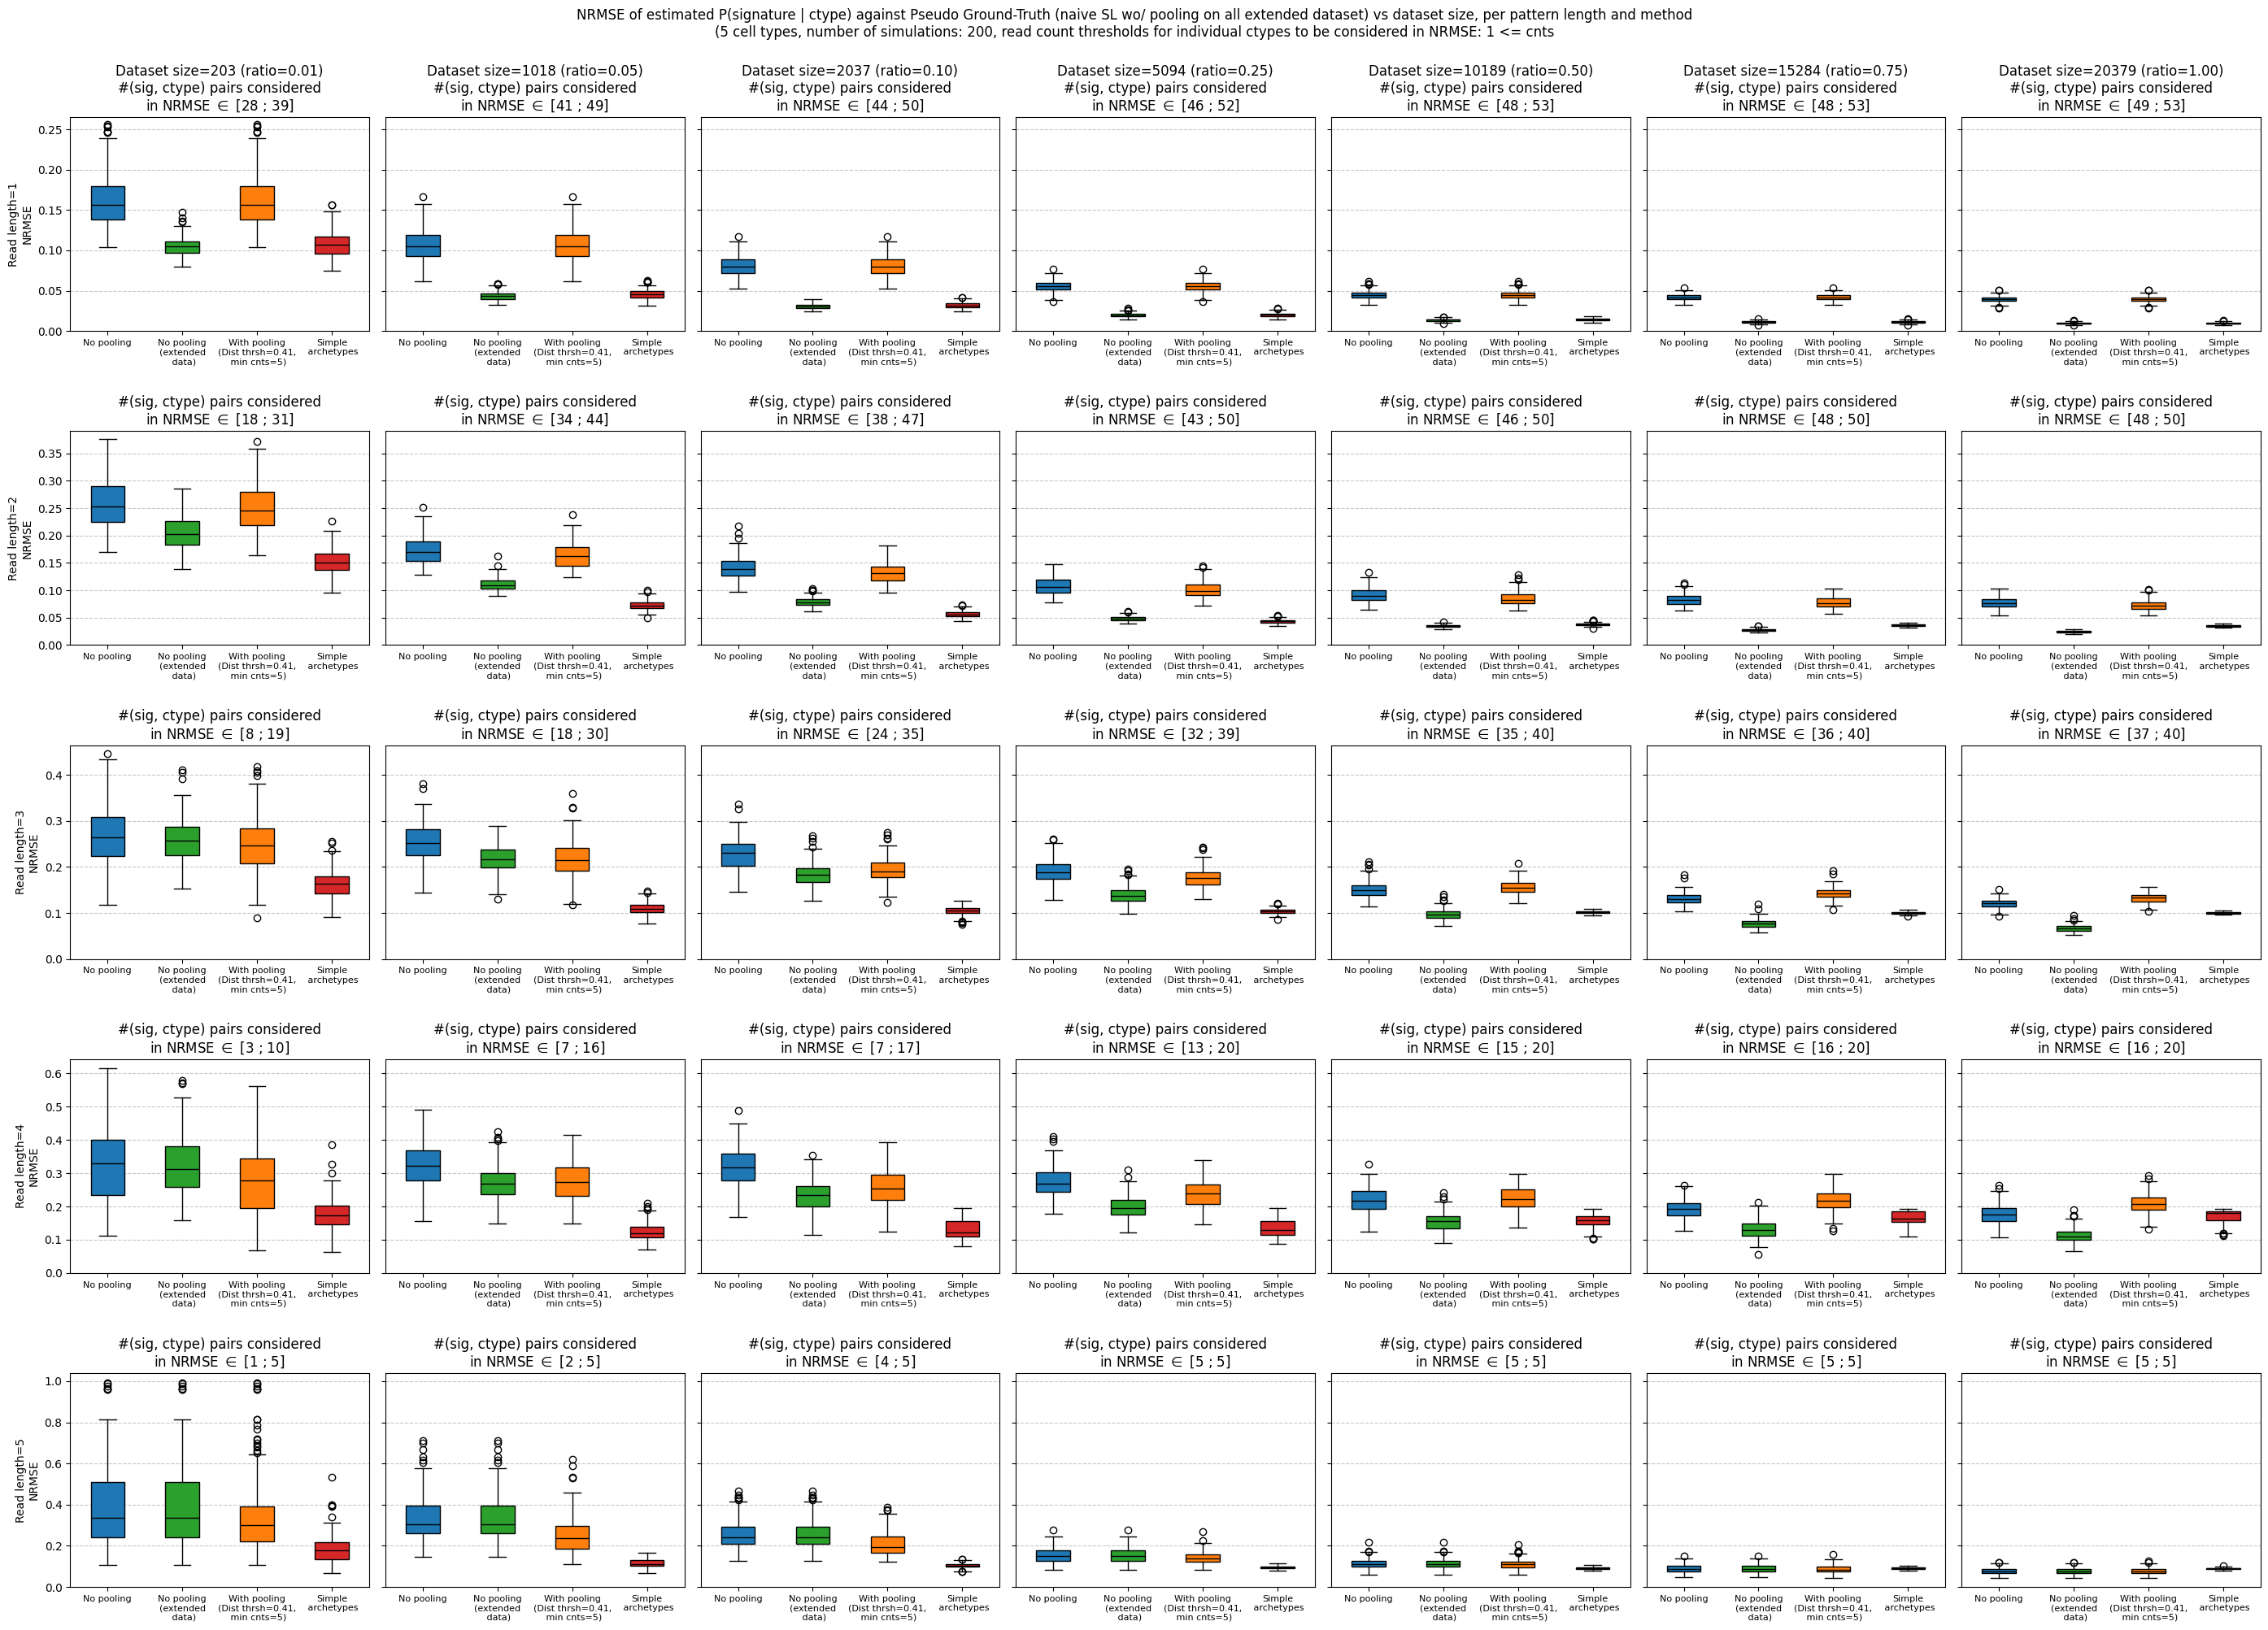

In [104]:
methods = [
    "naive_sl_without_pooling",
    "naive_sl_without_pooling_complete_data",
    "naive_sl_with_pooling",
    "sl_with_simple_archetypes",
]
methods_using_complete_data = [
    "naive_sl_without_pooling_complete_data",
]
method_labels = [
    "No pooling",
    "No pooling\n(extended\n data)",
    "With pooling\n(Dist thrsh=0.41,\n min cnts=5)",
    "Simple\n archetypes",
]
colors = ["tab:blue", "tab:green", "tab:orange", "tab:red"]

fig, axes = plt.subplots(
    5, len(ratio_grid), figsize=(4 * len(ratio_grid), 4 * 5), sharey="row"
)

for row_idx, read_length in enumerate(range(1, 6)):
    for col_idx, dataset_size in enumerate(dataset_sizes_grid):
        ax = axes[row_idx, col_idx]
        data_to_plot = []
        for method in methods:
            nrmse_list = results_per_size_per_read_length_per_method[dataset_size][
                read_length
            ][method]
            data_to_plot.append(nrmse_list)

        bp = ax.boxplot(data_to_plot, patch_artist=True, tick_labels=method_labels)

        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color)

        for median in bp["medians"]:
            median.set_color("black")

        ax.set_ylim(0, None)

        # extract the min and max number of (sig_ctype) pairs considered in the NRMSE computation across all bootstrap samples for this read length and dataset size
        min_sig_ctype_pairs = min(
            num_sig_ctype_pairs_considered_per_length_per_size_per_data_type[
                dataset_size
            ][read_length]["normal_data"]
        )
        max_sig_ctype_pairs = max(
            num_sig_ctype_pairs_considered_per_length_per_size_per_data_type[
                dataset_size
            ][read_length]["normal_data"]
        )

        tmp_title = ""
        if row_idx == 0:
            tmp_title += f"Dataset size={dataset_size} (ratio={dataset_size/size_og_dataset:.2f})"
        tmp_title += (
            "\n#(sig, ctype) pairs considered\nin NRMSE "
            + r"$\in$"
            + f" [{min_sig_ctype_pairs} ; {max_sig_ctype_pairs}]"
        )
        ax.set_title(tmp_title)
        ax.grid(axis="y", linestyle="--", alpha=0.7)
        ax.set_xticklabels(method_labels, rotation=0, fontsize=8)
        ax.set_ylabel(f"Read length={read_length}\nNRMSE" if col_idx == 0 else "")
fig.suptitle(
    "NRMSE of estimated P(signature | ctype) against Pseudo Ground-Truth (naive SL wo/ pooling on all extended dataset) vs dataset size, per pattern length and method"
    f"\n({N_CTYPES} cell types, number of simulations: {N_BOOTSTRAP_SAMPLES}, read count thresholds for individual ctypes to be considered in NRMSE: {min_count_threshold_per_ctype_for_nrmse} <= cnts",
    y=1.0,
)
plt.tight_layout()
plt.savefig(
    "./output/nrmse_of_p_sig_given_ctype_vs_dataset_size_and_pattern_length.pdf",
    bbox_inches="tight",
)
plt.show()

#### Subexperiment (no oracle prior leakage): compare P(ctype | signature) directly

In this subexperiment, we compare the two naive methods directly on their estimation of P(ctype | signature), against the pseudo ground truth of P(ctype | signature).

This avoids converting from P(ctype | signature) to P(signature | ctype), and therefore avoids any dependence on an oracle P(signature) prior.

In [100]:
N_BOOTSTRAP_SAMPLES_ctype_given_sig = 200
ratio_grid_ctype_given_sig = np.array([0.01, 0.1, 0.2, 0.3, 1.0])
min_count_threshold_per_signature_for_nrmse = 1
max_count_threshold_per_signature_for_nrmse = 5
n_ratios_to_test_ctype_given_sig = len(ratio_grid_ctype_given_sig)
size_og_dataset_ctype_given_sig = compute_num_reads_in_dataset(og_dataset)
dataset_sizes_grid_ctype_given_sig = np.array(
    [
        int(size_og_dataset_ctype_given_sig * ratio)
        for ratio in ratio_grid_ctype_given_sig
    ]
)

results_ctype_given_sig_per_size_per_read_length_per_method = {
    ds: {
        i: {
            "naive_sl_without_pooling": [],
            "naive_sl_with_pooling": [],
        }
        for i in range(1, 6)
    }
    for ds in dataset_sizes_grid_ctype_given_sig
}
results_ctype_given_sig_per_size_per_read_length_per_method_with_max_threshold = {
    ds: {
        i: {
            "naive_sl_without_pooling": [],
            "naive_sl_with_pooling": [],
        }
        for i in range(1, 6)
    }
    for ds in dataset_sizes_grid_ctype_given_sig
}
sigs_considered_per_size_per_read_length_ctype_given_sig_per_method = {
    ds: {
        i: {
            "naive_sl_with_pooling": [],
            "naive_sl_without_pooling": [],
        }
        for i in range(1, 6)
    }
    for ds in dataset_sizes_grid_ctype_given_sig
}
sigs_considered_per_size_per_read_length_ctype_given_sig_per_method_with_max_threshold = {
    ds: {
        i: {
            "naive_sl_with_pooling": [],
            "naive_sl_without_pooling": [],
        }
        for i in range(1, 6)
    }
    for ds in dataset_sizes_grid_ctype_given_sig
}

n_loops = n_ratios_to_test_ctype_given_sig * N_BOOTSTRAP_SAMPLES_ctype_given_sig
with tqdm(
    total=n_loops, desc="Bootstrap sampling and computing NRMSE for P(ctype|sig)"
) as pbar:
    for dataset_size in dataset_sizes_grid_ctype_given_sig:
        for sim_id in range(N_BOOTSTRAP_SAMPLES_ctype_given_sig):
            bootstrap_dataset = generate_bootstrap_sample_from_dataset(
                og_dataset,
                dataset_size_to_sample=dataset_size,
            )
            bootstrap_counts_sig_per_ctype = compute_counts_sig_per_ctype_from_dataset(
                bootstrap_dataset,
                signature_positions,
                selected_ctypes,
                N_CTYPES,
            )

            naive_sl_without_pooling_ctype_given_sig_bootstrap = (
                naive_sl_without_pooling_ctype_given_sig(bootstrap_counts_sig_per_ctype)
            )
            _, naive_sl_with_pooling_ctype_given_sig_bootstrap = naive_sl_with_pooling(
                bootstrap_counts_sig_per_ctype, og_pgt_sig_prior, min_counts=5
            )

            # (
            #     nrmse_without_pooling_ctype_given_sig,
            #     num_sigs_considered_per_length_wo_pooling,
            # ) = compute_nrmse_per_sig_length_ctype_given_sig(
            #     naive_sl_without_pooling_ctype_given_sig_bootstrap,
            #     pgt_naive_sl_ctype_given_sig,
            #     counts_sig_per_ctype=bootstrap_counts_sig_per_ctype,
            #     min_count_threshold_per_signature=min_count_threshold_per_signature_for_nrmse,
            # )
            # (
            #     nrmse_with_pooling_ctype_given_sig,
            #     num_sigs_considered_per_length_w_pooling,
            # ) = compute_nrmse_per_sig_length_ctype_given_sig(
            #     naive_sl_with_pooling_ctype_given_sig_bootstrap,
            #     pgt_naive_sl_ctype_given_sig,
            #     counts_sig_per_ctype=bootstrap_counts_sig_per_ctype,
            #     min_count_threshold_per_signature=min_count_threshold_per_signature_for_nrmse,
            # )
            (
                nrmse_without_pooling_ctype_given_sig_with_max_threshold,
                num_sigs_considered_per_length_wo_pooling_with_max_threshold,
            ) = compute_nrmse_per_sig_length_ctype_given_sig(
                naive_sl_without_pooling_ctype_given_sig_bootstrap,
                pgt_naive_sl_ctype_given_sig,
                counts_sig_per_ctype=bootstrap_counts_sig_per_ctype,
                min_count_threshold_per_signature=min_count_threshold_per_signature_for_nrmse,
                max_count_threshold_per_signature=max_count_threshold_per_signature_for_nrmse,
            )
            (
                nrmse_with_pooling_ctype_given_sig_with_max_threshold,
                num_sigs_considered_per_length_w_pooling_with_max_threshold,
            ) = compute_nrmse_per_sig_length_ctype_given_sig(
                naive_sl_with_pooling_ctype_given_sig_bootstrap,
                pgt_naive_sl_ctype_given_sig,
                counts_sig_per_ctype=bootstrap_counts_sig_per_ctype,
                min_count_threshold_per_signature=min_count_threshold_per_signature_for_nrmse,
                max_count_threshold_per_signature=max_count_threshold_per_signature_for_nrmse,
            )

            for read_length in range(1, 6):
                # if read_length in nrmse_without_pooling_ctype_given_sig:
                #     results_ctype_given_sig_per_size_per_read_length_per_method[
                #         dataset_size
                #     ][read_length]["naive_sl_without_pooling"].append(
                #         nrmse_without_pooling_ctype_given_sig[read_length]
                #     )
                # if read_length in nrmse_with_pooling_ctype_given_sig:
                #     results_ctype_given_sig_per_size_per_read_length_per_method[
                #         dataset_size
                #     ][read_length]["naive_sl_with_pooling"].append(
                #         nrmse_with_pooling_ctype_given_sig[read_length]
                #     )
                if (
                    read_length
                    in nrmse_without_pooling_ctype_given_sig_with_max_threshold
                ):
                    results_ctype_given_sig_per_size_per_read_length_per_method_with_max_threshold[
                        dataset_size
                    ][
                        read_length
                    ][
                        "naive_sl_without_pooling"
                    ].append(
                        nrmse_without_pooling_ctype_given_sig_with_max_threshold[
                            read_length
                        ]
                    )
                if read_length in nrmse_with_pooling_ctype_given_sig_with_max_threshold:
                    results_ctype_given_sig_per_size_per_read_length_per_method_with_max_threshold[
                        dataset_size
                    ][
                        read_length
                    ][
                        "naive_sl_with_pooling"
                    ].append(
                        nrmse_with_pooling_ctype_given_sig_with_max_threshold[
                            read_length
                        ]
                    )
                # if read_length in num_sigs_considered_per_length_w_pooling:
                #     sigs_considered_per_size_per_read_length_ctype_given_sig_per_method[
                #         dataset_size
                #     ][read_length]["naive_sl_with_pooling"].append(
                #         num_sigs_considered_per_length_w_pooling[read_length]
                #     )
                # if read_length in num_sigs_considered_per_length_wo_pooling:
                #     sigs_considered_per_size_per_read_length_ctype_given_sig_per_method[
                #         dataset_size
                #     ][read_length]["naive_sl_without_pooling"].append(
                #         num_sigs_considered_per_length_wo_pooling[read_length]
                # )
                if (
                    read_length
                    in num_sigs_considered_per_length_w_pooling_with_max_threshold
                ):
                    sigs_considered_per_size_per_read_length_ctype_given_sig_per_method_with_max_threshold[
                        dataset_size
                    ][
                        read_length
                    ][
                        "naive_sl_with_pooling"
                    ].append(
                        num_sigs_considered_per_length_w_pooling_with_max_threshold[
                            read_length
                        ]
                    )
                if (
                    read_length
                    in num_sigs_considered_per_length_wo_pooling_with_max_threshold
                ):
                    sigs_considered_per_size_per_read_length_ctype_given_sig_per_method_with_max_threshold[
                        dataset_size
                    ][
                        read_length
                    ][
                        "naive_sl_without_pooling"
                    ].append(
                        num_sigs_considered_per_length_wo_pooling_with_max_threshold[
                            read_length
                        ]
                    )
            pbar.update(1)

Bootstrap sampling and computing NRMSE for P(ctype|sig):   0%|          | 0/1000 [00:00<?, ?it/s]/tmp/ipykernel_4056545/2424655524.py:27: RuntimeWarning: invalid value encountered in divide
  read_length: (counts / counts.sum(axis=0, keepdims=True)).T
/tmp/ipykernel_4056545/507213427.py:95: RuntimeWarning: invalid value encountered in divide
  proba_sig_given_ctype = proba_sig_given_ctype / proba_sig_given_ctype.sum(
Bootstrap sampling and computing NRMSE for P(ctype|sig): 100%|██████████| 1000/1000 [03:01<00:00,  5.52it/s]


In [95]:
# ## PLOTTING THE RESULTS WITH MIN BUT WITHOUT MAX THRESHOLD

# methods_ctype_given_sig = ["naive_sl_without_pooling", "naive_sl_with_pooling"]
# method_labels_ctype_given_sig = ["No pooling", "With pooling"]
# colors_ctype_given_sig = ["tab:orange", "tab:green"]

# fig, axes = plt.subplots(
#     5,
#     len(ratio_grid_ctype_given_sig),
#     figsize=(4 * len(ratio_grid_ctype_given_sig), 4 * 5),
#     sharey="row",
# )


# # first we compute the maximum y-axis limit per row (read length) across all dataset sizes and methods, to have a common y-axis limit per row
# max_y_per_row = {}
# for row_idx, read_length in enumerate(range(1, 6)):
#     max_y = 0
#     for col_idx, dataset_size in enumerate(dataset_sizes_grid_ctype_given_sig):
#         for method in methods_ctype_given_sig:
#             nrmse_list = results_ctype_given_sig_per_size_per_read_length_per_method[
#                 dataset_size
#             ][read_length][method]
#             if len(nrmse_list) > 0:
#                 max_y = max(max_y, max(nrmse_list))
#     max_y_per_row[read_length] = max_y

# for row_idx, read_length in enumerate(range(1, 6)):
#     for col_idx, dataset_size in enumerate(dataset_sizes_grid_ctype_given_sig):
#         ax = axes[row_idx, col_idx]

#         # Sig count annotation for this read length and dataset size, per method
#         sig_count_info = ""
#         for method in methods_ctype_given_sig[
#             :1
#         ]:  # only show sig count annotation for the first method to avoid clutter, since the sig counts are the same for both methods
#             tmp_sigs_considered = np.array(
#                 sigs_considered_per_size_per_read_length_ctype_given_sig_per_method[
#                     dataset_size
#                 ][read_length][method],
#                 dtype=float,
#             )
#             if tmp_sigs_considered.size > 0:
#                 sigs_considered_med = int(np.median(tmp_sigs_considered))
#                 sigs_considered_min = int(np.percentile(tmp_sigs_considered, 25))
#                 sigs_considered_max = int(np.percentile(tmp_sigs_considered, 75))
#                 sig_count_info += f"\nNum sigs considered: min={sigs_considered_min}, max={sigs_considered_max}"
#             else:
#                 sig_count_info += f"\nNum sigs considered: n/a"

#         data_to_plot = []
#         for method in methods_ctype_given_sig:
#             nrmse_list = results_ctype_given_sig_per_size_per_read_length_per_method[
#                 dataset_size
#             ][read_length][method]
#             data_to_plot.append(nrmse_list)

#         bp = ax.boxplot(
#             data_to_plot,
#             patch_artist=True,
#             tick_labels=method_labels_ctype_given_sig,
#         )

#         for patch, color in zip(bp["boxes"], colors_ctype_given_sig):
#             patch.set_facecolor(color)

#         for median in bp["medians"]:
#             median.set_color("black")

#         ax.set_ylim(0, 1.01 * max_y_per_row[read_length])
#         if row_idx == 0:
#             ax.set_title(
#                 f"Dataset size = {dataset_size} (ratio={dataset_size/size_og_dataset_ctype_given_sig:.2f})"
#                 f"{sig_count_info}"
#             )
#         else:
#             ax.set_title(f"{sig_count_info}")

#         ax.set_xticklabels(method_labels_ctype_given_sig, rotation=0, fontsize=8)
#         ax.set_ylabel(f"Pattern length={read_length}\nNRMSE" if col_idx == 0 else "")

# fig.suptitle(
#     "NRMSE of P(ctype | sig) estimation vs dataset size, per pattern length and method"
#     f"\n({N_CTYPES} cell types, number of simulations: {N_BOOTSTRAP_SAMPLES_ctype_given_sig}, read count thresholds for individual sigs to be considered in NRMSE: {min_count_threshold_per_signature_for_nrmse} <= cnts",
#     y=1.0,
# )
# # plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.tight_layout()
# plt.show()

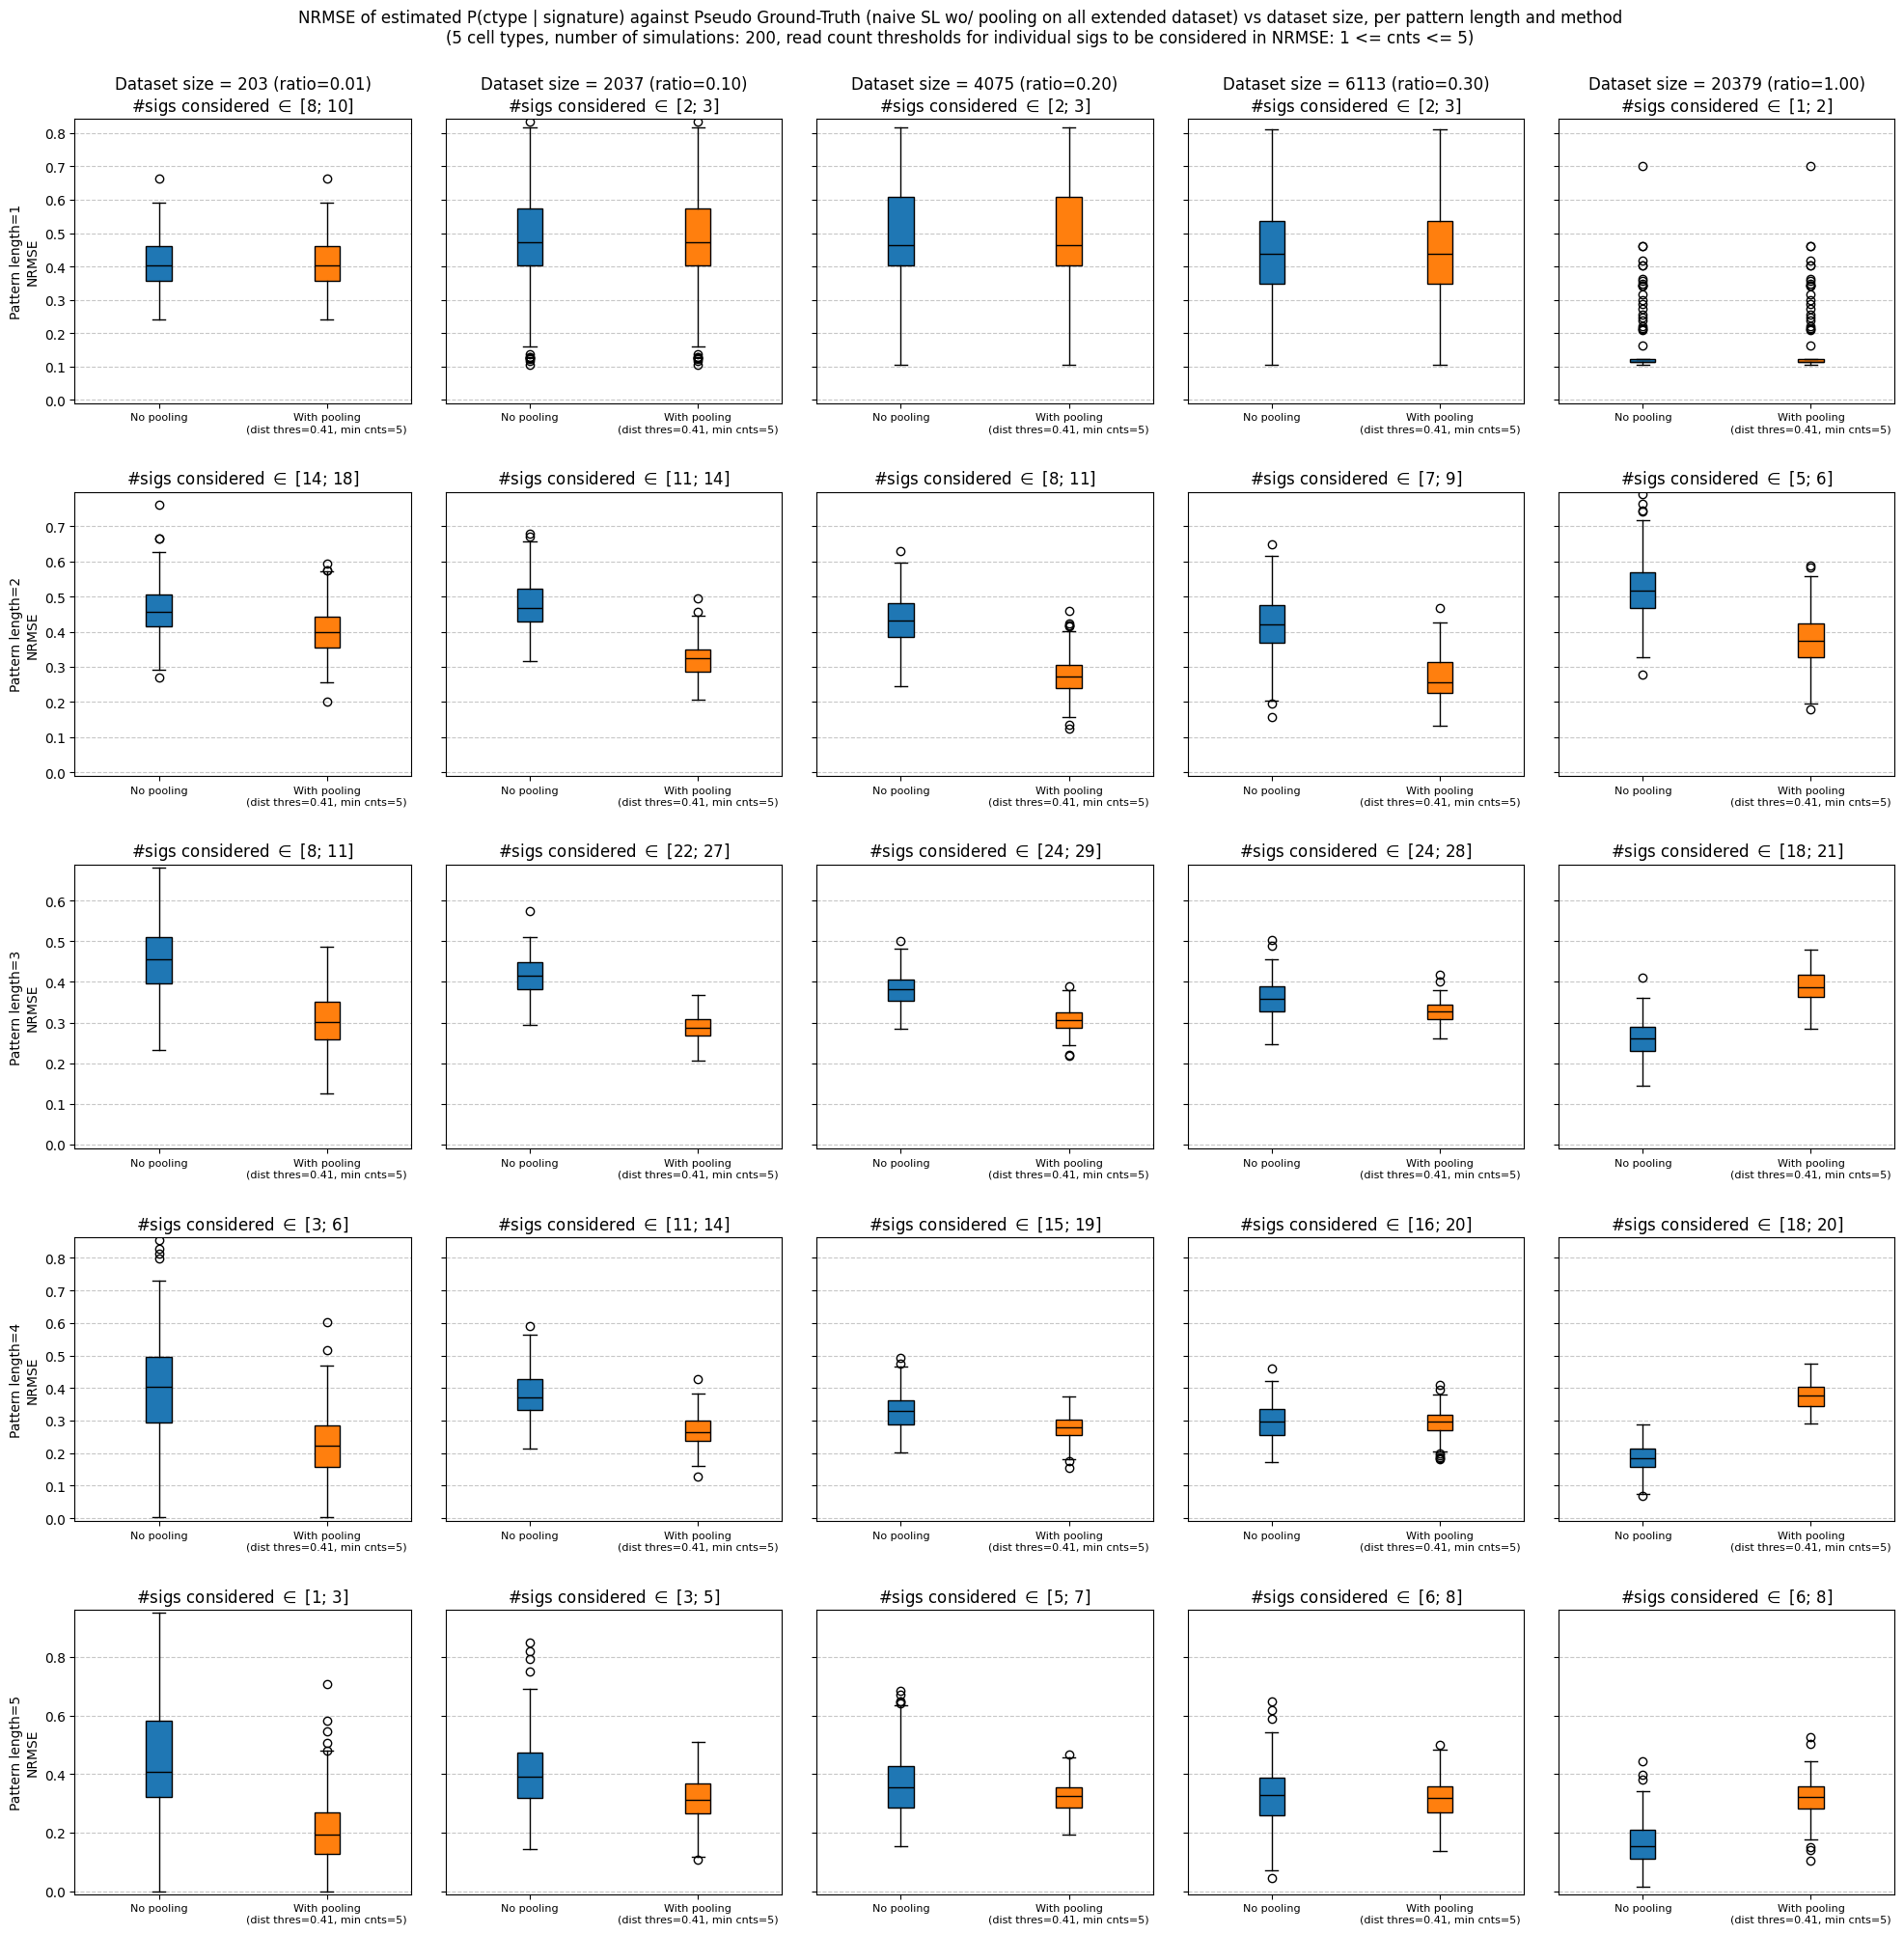

In [103]:
## PLOTTING THE RESULTS WITH MIN AND MAX THRESHOLD
methods_ctype_given_sig = ["naive_sl_without_pooling", "naive_sl_with_pooling"]
method_labels_ctype_given_sig = [
    "No pooling",
    "With pooling\n(dist thres=0.41, min cnts=5)",
]
colors_ctype_given_sig = ["tab:blue", "tab:orange"]

fig, axes = plt.subplots(
    5,
    len(ratio_grid_ctype_given_sig),
    figsize=(4 * len(ratio_grid_ctype_given_sig), 4 * 5),
    sharey="row",
)

# to avoid plotting boxplots that use avg NRMSEs computed from very few signatures
MINIMUM_MIN_SIG_CONSIDERED_FOR_PLOTTING = 5

# first we compute the maximum y-axis limit per row (read length) across all dataset sizes and methods, to have a common y-axis limit per row
max_y_per_row = {}
for row_idx, read_length in enumerate(range(1, 6)):
    max_y = 0
    for col_idx, dataset_size in enumerate(dataset_sizes_grid_ctype_given_sig):
        for method in methods_ctype_given_sig:
            nrmse_list = results_ctype_given_sig_per_size_per_read_length_per_method_with_max_threshold[
                dataset_size
            ][
                read_length
            ][
                method
            ]
            if len(nrmse_list) > 0:
                max_y = max(max_y, max(nrmse_list))
    max_y_per_row[read_length] = max_y

for row_idx, read_length in enumerate(range(1, 6)):
    for col_idx, dataset_size in enumerate(dataset_sizes_grid_ctype_given_sig):
        ax = axes[row_idx, col_idx]

        # Sig count annotation for this read length and dataset size, per method
        sig_count_info = ""
        for method in methods_ctype_given_sig[
            :1
        ]:  # only show sig count annotation for the first method to avoid clutter, since the sig counts are the same for both methods
            tmp_sigs_considered = np.array(
                sigs_considered_per_size_per_read_length_ctype_given_sig_per_method_with_max_threshold[
                    dataset_size
                ][
                    read_length
                ][
                    method
                ],
                dtype=float,
            )
            if tmp_sigs_considered.size > 0:
                sigs_considered_med = int(np.median(tmp_sigs_considered))
                sigs_considered_min = int(np.percentile(tmp_sigs_considered, 25))
                sigs_considered_max = int(np.percentile(tmp_sigs_considered, 75))
                sig_count_info += (
                    "\n#sigs considered "
                    + r"$\in$"
                    + f" [{sigs_considered_min}; {sigs_considered_max}]"
                )
            else:
                sig_count_info += "\n#sigs considered: n/a"

        data_to_plot = []
        for method in methods_ctype_given_sig:
            nrmse_list = results_ctype_given_sig_per_size_per_read_length_per_method_with_max_threshold[
                dataset_size
            ][
                read_length
            ][
                method
            ]
            data_to_plot.append(nrmse_list)

        bp = ax.boxplot(
            data_to_plot,
            patch_artist=True,
            tick_labels=method_labels_ctype_given_sig,
        )

        for patch, color in zip(bp["boxes"], colors_ctype_given_sig):
            patch.set_facecolor(color)

        for median in bp["medians"]:
            median.set_color("black")

        ax.set_ylim(-0.01, 1.01 * max_y_per_row[read_length])
        if row_idx == 0:
            ax.set_title(
                f"Dataset size = {dataset_size} (ratio={dataset_size/size_og_dataset_ctype_given_sig:.2f})"
                f"{sig_count_info}"
            )
        else:
            ax.set_title(f"{sig_count_info}")
        ax.grid(axis="y", linestyle="--", alpha=0.7)
        ax.set_xticklabels(method_labels_ctype_given_sig, rotation=0, fontsize=8)
        ax.set_ylabel(f"Pattern length={read_length}\nNRMSE" if col_idx == 0 else "")

fig.suptitle(
    "NRMSE of estimated P(ctype | signature) against Pseudo Ground-Truth (naive SL wo/ pooling on all extended dataset) vs dataset size, per pattern length and method"
    f"\n({N_CTYPES} cell types, number of simulations: {N_BOOTSTRAP_SAMPLES_ctype_given_sig}, read count thresholds for individual sigs to be considered in NRMSE: {min_count_threshold_per_signature_for_nrmse} <= cnts <= {max_count_threshold_per_signature_for_nrmse})",
    y=1.0,
)
# plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.tight_layout()
plt.savefig(
    "./output/nrmse_of_p_ctype_given_sig_vs_dataset_size_and_pattern_length_with_max_threshold_at_5.pdf",
    bbox_inches="tight",
)
plt.show()

In [97]:
tmp_wo_pool = np.array(
    results_ctype_given_sig_per_size_per_read_length_per_method_with_max_threshold[203][
        1
    ]["naive_sl_without_pooling"]
)
tmp_w_pool = np.array(
    results_ctype_given_sig_per_size_per_read_length_per_method_with_max_threshold[203][
        1
    ]["naive_sl_with_pooling"]
)

In [98]:
np.isclose(tmp_wo_pool, tmp_w_pool, equal_nan=True).all()

np.True_